In [1]:
import random;
import itertools;
import time;
import statistics;
import matplotlib.pyplot as plt;
import math;

### DATA GENERATION

In [2]:
def generateDataSet(n, D, alpha):
    T = n * D * alpha
    intervals = []
    for _ in range(0, n):
        s = random.randint(0,T)
        d = random.randint(1,D)
        f = s + d

        intervals.append((s,f))


    return intervals

### GREEDY EFT

In [3]:
def greedy_eft(data):
    selected_tasks = [] 
    
    data.sort(key=lambda x: x[1])

    selected_tasks.append(data[0])
    current_end = data[0][1]

    for l in range(0, len(data)):
        if data[l][0] >= current_end:
            selected_tasks.append(data[l])
            current_end = data[l][1]

    return selected_tasks

### GREEDY EST

In [4]:
def greedy_est(data):

    data.sort(key=lambda x: x[0])
        
    selected_tasks = []
    selected_tasks.append(data[0])
    current_end = data[0][1]

    for k in range(1, len(data)):
        if (data[k][0] >= current_end ):
            selected_tasks.append(data[k])
            current_end = data[k][1]

    return selected_tasks

### GREEDY ST

In [5]:
def greedy_st(data):
    data.sort(key=lambda x: x[1] - x[0])
        
    selected_tasks = []
    selected_tasks.append(data[0])
    current_end = data[0][1]
    for k in range(1, len(data)):
        if data[k][0] >= current_end:
            selected_tasks.append(data[k])
            current_end = data[k][1]

    return selected_tasks

### BRUTE FORCE METHOD (EXHAUSTIVE)

In [6]:
def brute_force(data):
    n = len(data)
    best = []

    for r in range(1, n+1):
        for subset in itertools.combinations(data, r):
            valid = True

            # INTERVAL COMPATIBILITY CHECK
            for i in range(len(subset)):
                for j in range(i+1, len(subset)):
                    a = subset[i]
                    b = subset[j]

                    if not (a[1] <= b[0] or b[1] <= a[0]):
                        valid = False
                        break

                
                if not valid:
                    break
            
            # LARGEST FEASIBLE SUBSET
            if valid and len(subset) > len(best):
                best = list(subset)

    return best
            

***TESTING***

In [7]:
data = generateDataSet(10, 10, 0.1)
print("DATA:")
print(data)
print("LENGTH:")
print(len(data))

start = time.perf_counter()
est_selected_data = greedy_est(data)
end = time.perf_counter()
print("INTERVALS SELECTED BY EARLIEST START ALGO:")
print(est_selected_data)
print("EST INTERVALS COUNT:")
print(len(est_selected_data))

print("OPTIMAL:")
brute_force(data)


eft_selected_data = greedy_eft(data)
print("INTERVALS SELECTED BY EARLIEST FINISH ALGO:")
print(eft_selected_data)
print("EFT INTERVALS COUNT:")
print(len(eft_selected_data))


sd_selected_data = greedy_st(data)
print("INTERVALS SELECTED BY SHORT DURATION ALGO:")
print(sd_selected_data)
print("SD INTERVALS COUNT:")
print(len(sd_selected_data))




DATA:
[(7, 8), (6, 7), (10, 13), (0, 8), (2, 9), (3, 12), (3, 7), (8, 13), (6, 16), (1, 4)]
LENGTH:
10
INTERVALS SELECTED BY EARLIEST START ALGO:
[(0, 8), (8, 13)]
EST INTERVALS COUNT:
2
OPTIMAL:
INTERVALS SELECTED BY EARLIEST FINISH ALGO:
[(1, 4), (6, 7), (7, 8), (8, 13)]
EFT INTERVALS COUNT:
4
INTERVALS SELECTED BY SHORT DURATION ALGO:
[(6, 7), (7, 8), (10, 13)]
SD INTERVALS COUNT:
3


# ANALYSIS OF ALGORITHMS

### GREEDY ALGORITHM TRIALS & DATA COLLECTION

In [8]:
sizes = [2**k for k in range(10, 20)]

eft_times = []
est_times = []
sd_times = []

eft_results = []
est_results = []
sd_results = []

for s in sizes:
    eft_times = []
    est_times = []
    sd_times = []

    # warm-up
    dummy = generateDataSet(1000, 10, 0.1)
    greedy_eft(dummy[:])
    greedy_est(dummy[:])
    greedy_st(dummy[:])


    for _ in range(10):
        data = generateDataSet(s, 10, 0.1)
        # data_copy = data[:]

        start = time.perf_counter()
        eft_data = greedy_eft(data[:])
        end = time.perf_counter()
        eft_times.append((end - start))
        
        start = time.perf_counter()
        est_data = greedy_est(data[:])
        end = time.perf_counter()
        est_times.append((end - start))
        
        start = time.perf_counter()
        sd_data = greedy_st(data[:])
        end = time.perf_counter()
        sd_times.append((end - start))

        
    eft_mean = statistics.mean(eft_times)
    eft_std = statistics.stdev(eft_times)
    
    est_mean = statistics.mean(est_times)
    est_std = statistics.stdev(est_times)
    
    sd_mean = statistics.mean(sd_times)
    sd_std = statistics.stdev(sd_times)

    eft_results.append((s, eft_mean, eft_std))
    est_results.append((s, est_mean, est_std))
    sd_results.append((s, sd_mean, sd_std))

print("EFT: ", eft_results)
print("EST: ", est_results)
print("ST: ", sd_results)

EFT:  [(1024, 0.00018996000289916992, 6.579968749355325e-05), (2048, 0.00036402000696398316, 1.7180014189488477e-05), (4096, 0.0007803099928423762, 0.00012297565211991703), (8192, 0.00184959999169223, 0.00025744680058490364), (16384, 0.004166230000555516, 0.000578330699025227), (32768, 0.009879640000872315, 0.0014286420856084632), (65536, 0.025778479996370153, 0.0015251140926763219), (131072, 0.06559782000258566, 0.0034944896564928028), (262144, 0.14152535000466743, 0.015092401377618725), (524288, 0.30109770000563, 0.029169554170254915)]
EST:  [(1024, 0.00016447000089101494, 4.093004792352385e-05), (2048, 0.00034861999447457495, 8.106175473475877e-05), (4096, 0.00066566999303177, 8.005819823982677e-05), (8192, 0.0015679900126997382, 0.00017754892402521702), (16384, 0.0037262799916788934, 0.00044502566211546336), (32768, 0.00858693000045605, 0.0009578945277639258), (65536, 0.0265259999781847, 0.0029997315356182093), (131072, 0.06855965998838656, 0.0054434112820632595), (262144, 0.149751

### GREEDY ALGORITHM DATA PLOT AND ANALYSIS

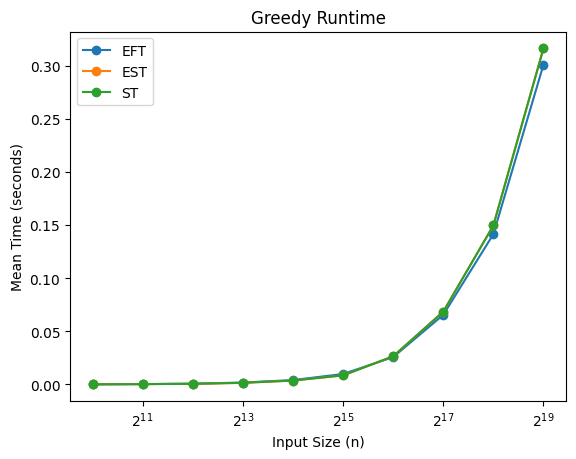

In [9]:
eft_sizes = []
eft_means = []
eft_stds = []

for s, mean, std in eft_results:
    eft_sizes.append(s)
    eft_means.append(mean)
    eft_stds.append(std)
    
est_sizes = []
est_means = []
est_stds = []

for s, mean, std in est_results:
    est_sizes.append(s)
    est_means.append(mean)
    est_stds.append(std)
    
st_sizes = []
st_means = []
st_stds = []

for s, mean, std in est_results:
    st_sizes.append(s)
    st_means.append(mean)
    st_stds.append(std)

plt.figure() 

plt.plot(eft_sizes, eft_means, marker='o', label="EFT")
plt.plot(est_sizes, est_means, marker='o', label="EST")
plt.plot(st_sizes, st_means, marker='o', label="ST")


plt.xscale("log", base=2)
plt.xlabel("Input Size (n)")
plt.ylabel("Mean Time (seconds)")
plt.title("Greedy Runtime")

plt.legend()
plt.show()

***MENTIONED IN ASSIGNMENT PDF;***

*We can see from the plotting of the results generated by greedy algorithms on **different sizes of input**, that the growth rate of the data in terms of different greedy algorithms are relatively the same since the different algorithms in interval scheduling only changes the solution and not the runtime. The time complexities of the data is dominated by sorting i.e. **O(n log n)***

### EXHAUSTIVE TRIALS & DATA COLLECTION

In [10]:
brute_sizes = [5, 10, 15, 20]

bf_times = []
bf_results = []

for bs in brute_sizes:
    data = generateDataSet(bs, 10, 0.1)
    bf_times = []

    #warm
    dummy = generateDataSet(5, 10, 0.1)
    brute_force(dummy[:])


    for _ in range(10):

        start = time.perf_counter()
        bs_data = brute_force(data[:])
        end = time.perf_counter()
        
        bf_times.append((end - start))

    bs_mean = statistics.mean(bf_times)
    bs_std = statistics.stdev(bf_times)
    
    bf_results.append((bs, bs_mean, bs_std))

    
print("Brute Force: ", bf_results)

Brute Force:  [(5, 1.110999728552997e-05, 7.922499968152322e-07), (10, 0.0005779799888841808, 0.00018535156569994302), (15, 0.012296829995466396, 0.0003792459841043559), (20, 0.6257581000158098, 0.008721290099133501)]


### EXHAUSTIVE  DATA PLOT AND ANALYSIS

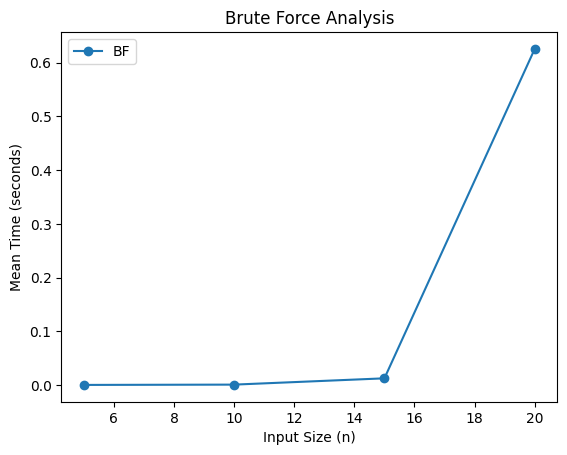

In [11]:
bf_sizes = []
bf_means = []
bf_stds = []

for s, mean, std in bf_results:
    bf_sizes.append(s)
    bf_means.append(mean)
    bf_stds.append(std)

plt.figure()
plt.plot(bf_sizes, bf_means, marker = 'o', label="BF")
plt.xlabel("Input Size (n)")
plt.ylabel("Mean Time (seconds)")
plt.title("Brute Force Analysis")

plt.legend()
plt.show()

*We can see from the graph that performing Brute Force algorithm exhibits rapid growth. Proving that the runtime is growing exponentially at the rate of O(n.2<sup>n</sup>)*

### **BIG O VALIDATION**

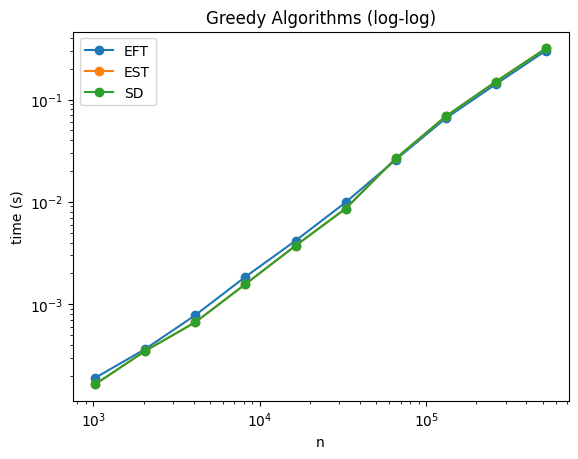

In [12]:
plt.figure()
plt.loglog(sizes, eft_means, marker='o', label="EFT")
plt.loglog(sizes, est_means, marker='o', label="EST")
plt.loglog(sizes, st_means, marker='o', label="SD")

plt.xlabel("n")

plt.ylabel("time (s)")
plt.legend()
plt.title("Greedy Algorithms (log-log)")
plt.show()


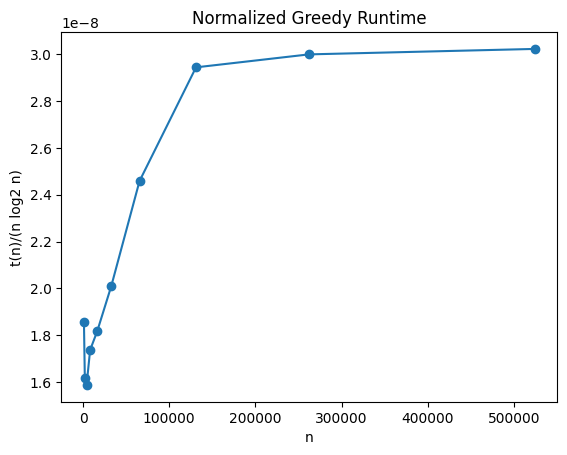

In [13]:
normalized = []

for (n, mean, std) in eft_results:
    normalized.append(mean / (n * math.log2(n)))

plt.figure()
plt.plot(sizes, normalized, marker='o')
plt.xlabel("n")
plt.ylabel("t(n)/(n log2 n)")
plt.title("Normalized Greedy Runtime")
plt.show()

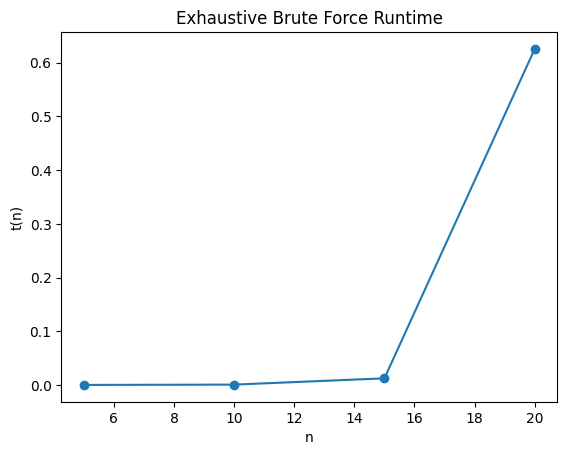

In [14]:
plt.figure()
plt.plot(bf_sizes, bf_means, marker='o')
plt.xlabel("n")
plt.ylabel("t(n)")
plt.title("Exhaustive Brute Force Runtime")
plt.show()

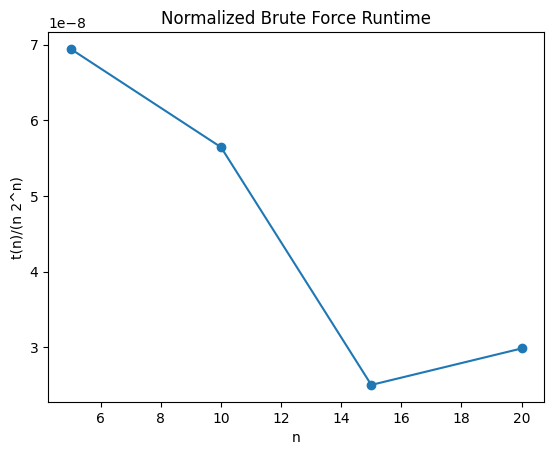

In [15]:
normalized_bf = []

for (n, mean, _) in bf_results:
    normalized_bf.append(mean / (n * (2**n)))

plt.figure()
plt.plot(bf_sizes, normalized_bf, marker='o')
plt.xlabel("n")
plt.ylabel("t(n)/(n 2^n)")
plt.title("Normalized Brute Force Runtime")
plt.show()



## PRUNING

***MENTIONED IN ASSIGNMENT PDF;***

*Pruning allows the algorithm to **discard incompatible interval subsets** early, reducing runtime by avoiding exploration of some branches of the search space. However, in the **worst case** where all intervals are mutually compatible, **no pruning occurs** anda every possible subset must still be examined. Therefore, pruning may improve performance for small inputs but does not change the worst-case exponential complexity, which remains O(n.2<sub>n<sub>)*

## TIME HORIZON VARIANCE

In [16]:
print(f"{'alpha':>6} | {'EFT':>6} | {'EST':>6} | {'SD':>6} | {'OPT':>6}")
print("-"*36)

alphas = [0.1, 1, 5]
n = 15

for alpha in alphas:
    eft = []
    est = []
    sd = []
    opt = []

    for _ in range(10):
        data = generateDataSet(n, 10, alpha)

        eft.append(len(greedy_eft(data[:])))
        est.append(len(greedy_est(data[:])))
        sd.append(len(greedy_st(data[:])))
        opt.append(len(brute_force(data[:])))

    print(f"{alpha:6.1f} | "
          f"{statistics.mean(eft):6.2f} | "
          f"{statistics.mean(est):6.2f} | "
          f"{statistics.mean(sd):6.2f} | "
          f"{statistics.mean(opt):6.2f}")


 alpha |    EFT |    EST |     SD |    OPT
------------------------------------
   0.1 |   3.80 |   3.30 |   2.40 |   3.80
   1.0 |  10.50 |  10.30 |   3.10 |  10.50
   5.0 |  13.80 |  13.70 |   3.70 |  13.80
